# Cafe Sales Data Analysis

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("dirty_cafe_sales.csv")


In [8]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [9]:
df.shape

(10000, 8)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [11]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [12]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


# Data Cleaning

# check the missing value

In [13]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# check the missing value in percentage


In [14]:
(df.isnull().sum()/len(df))*100

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

# Missing values were identified to understand data quality issues before analysis.

# check the duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df[df.duplicated()]

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date


In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

# check the size columns and rows

In [19]:
df.shape

(10000, 8)

In [20]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [21]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [22]:
df['Quantity'].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [23]:
df['Transaction ID'].unique()

array(['TXN_1961373', 'TXN_4977031', 'TXN_4271903', ..., 'TXN_5255387',
       'TXN_7695629', 'TXN_6170729'], shape=(10000,), dtype=object)

In [24]:
df['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [25]:
df['Total Spent'].unique()

array(['4.0', '12.0', 'ERROR', '10.0', '20.0', '9.0', '16.0', '15.0',
       '25.0', '8.0', '5.0', '3.0', '6.0', nan, 'UNKNOWN', '2.0', '1.0',
       '7.5', '4.5', '1.5'], dtype=object)

In [26]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan],
      dtype=object)

In [27]:
df['Location'].unique()

array(['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR'], dtype=object)

In [28]:
df['Transaction Date'].unique()

array(['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27',
       '2023-06-11', '2023-03-31', '2023-10-06', '2023-10-28',
       '2023-07-28', '2023-12-31', '2023-11-07', 'ERROR', '2023-05-03',
       '2023-06-01', '2023-03-21', '2023-11-15', '2023-06-10',
       '2023-02-24', '2023-03-25', '2023-01-15', '2023-04-04',
       '2023-03-30', '2023-12-01', '2023-09-18', '2023-06-03',
       '2023-12-13', '2023-04-20', '2023-04-10', '2023-03-11',
       '2023-06-02', '2023-11-06', '2023-08-15', '2023-10-09',
       '2023-05-28', '2023-07-17', '2023-04-29', '2023-06-08',
       '2023-06-29', '2023-04-17', '2023-12-22', '2023-01-10',
       '2023-10-02', '2023-02-23', '2023-03-22', '2023-11-03',
       '2023-03-02', '2023-06-26', '2023-05-02', '2023-09-05',
       '2023-01-08', '2023-03-15', '2023-11-25', '2023-12-05',
       '2023-03-19', '2023-06-27', '2023-04-19', '2023-10-07',
       '2023-09-30', '2023-05-27', '2023-11-18', '2023-10-20',
       '2023-10-03', '2023-10-27', '2023-04-06

# Analysis the data where we get the unknow , error and nan so make it value nan using the numpy

In [29]:
values=[
'N/A',
    'Not Available',
    'NOT AVAILABLE',
    'not available',
    "UNKNOWN",
    'ERROR',
]

df.replace(values,np.nan,inplace=True)

In [30]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', nan, 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [31]:
df['Item']

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: object

In [32]:
df['Item'].fillna(df['Item'].mode()[0], inplace=True)

# Reasons to used this 

The Item column is a categorical variable because it contains product names such as Coffee, Cake, Sandwich, and Tea. For categorical data, statistical measures like the mean or median cannot be used.

In [33]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice',
       'Sandwich', 'Tea'], dtype=object)

# For Qty 

In [34]:
df['Quantity'].unique()

array(['2', '4', '5', '3', '1', nan], dtype=object)

# convert to numeric first and after fill and convert to int 

In [35]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [36]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [37]:
df['Quantity'] = df['Quantity'].astype(int)

In [38]:
df['Quantity'].dtype

dtype('int64')

In [39]:
df['Quantity'].unique()

array([2, 4, 5, 3, 1])

# For Price Per Unit

In [40]:
df['Price Per Unit'].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan], dtype=object)

In [41]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

In [42]:
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Price Per Unit'].median())

In [43]:
df['Price Per Unit'].isnull().sum()

np.int64(0)

In [44]:
df['Quantity'] = df['Quantity'].astype(float)

In [45]:
df['Quantity'].dtype

dtype('float64')

# For Total Spent

In [46]:
df['Total Spent'].unique()

array(['4.0', '12.0', nan, '10.0', '20.0', '9.0', '16.0', '15.0', '25.0',
       '8.0', '5.0', '3.0', '6.0', '2.0', '1.0', '7.5', '4.5', '1.5'],
      dtype=object)

In [47]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [48]:
df['Total Spent'] = df['Total Spent'].fillna(df['Total Spent'].median())

In [49]:
df['Total Spent'].isnull().sum()

np.int64(0)

In [50]:
df['Total Spent'] = df['Total Spent'].astype(float)

In [51]:
df['Quantity'].dtype

dtype('float64')

# For Payment Methods 

In [52]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', nan, 'Digital Wallet'], dtype=object)

In [53]:
df['Payment Method'] = df['Payment Method'].fillna(
    df['Payment Method'].mode()[0]
)

In [54]:
print(df['Payment Method'].isnull().sum())

0


# For Locations

In [55]:
df['Location'].unique()

array(['Takeaway', 'In-store', nan], dtype=object)

In [56]:
df['Location'] = df['Location'].fillna(
    df['Location'].mode()[0]
)

In [57]:
print(df['Location'].isnull().sum())

0


#  For Date

In [58]:
df['Transaction Date'].unique()

array(['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27',
       '2023-06-11', '2023-03-31', '2023-10-06', '2023-10-28',
       '2023-07-28', '2023-12-31', '2023-11-07', nan, '2023-05-03',
       '2023-06-01', '2023-03-21', '2023-11-15', '2023-06-10',
       '2023-02-24', '2023-03-25', '2023-01-15', '2023-04-04',
       '2023-03-30', '2023-12-01', '2023-09-18', '2023-06-03',
       '2023-12-13', '2023-04-20', '2023-04-10', '2023-03-11',
       '2023-06-02', '2023-11-06', '2023-08-15', '2023-10-09',
       '2023-05-28', '2023-07-17', '2023-04-29', '2023-06-08',
       '2023-06-29', '2023-04-17', '2023-12-22', '2023-01-10',
       '2023-10-02', '2023-02-23', '2023-03-22', '2023-11-03',
       '2023-03-02', '2023-06-26', '2023-05-02', '2023-09-05',
       '2023-01-08', '2023-03-15', '2023-11-25', '2023-12-05',
       '2023-03-19', '2023-06-27', '2023-04-19', '2023-10-07',
       '2023-09-30', '2023-05-27', '2023-11-18', '2023-10-20',
       '2023-10-03', '2023-10-27', '2023-04-06', '

In [59]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

In [60]:
df['Transaction Date'].isnull().sum()

np.int64(460)

In [61]:
df['Transaction Date'] = df['Transaction Date'].fillna(df['Transaction Date'].mode()[0])

In [62]:
print(df['Transaction Date'].isnull().sum())

0


In [63]:
(df.isnull().sum()/len(df))*100

Transaction ID      0.0
Item                0.0
Quantity            0.0
Price Per Unit      0.0
Total Spent         0.0
Payment Method      0.0
Location            0.0
Transaction Date    0.0
dtype: float64

In [64]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [65]:
(df.isnull().sum()/len(df))*100

Transaction ID      0.0
Item                0.0
Quantity            0.0
Price Per Unit      0.0
Total Spent         0.0
Payment Method      0.0
Location            0.0
Transaction Date    0.0
dtype: float64

In [66]:
df['Transaction Date'].unique()

<DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-06 00:00:00', '2023-10-28 00:00:00', '2023-07-28 00:00:00',
 '2023-12-31 00:00:00',
 ...
 '2023-08-01 00:00:00', '2023-01-20 00:00:00', '2023-11-11 00:00:00',
 '2023-02-13 00:00:00', '2023-07-30 00:00:00', '2023-02-17 00:00:00',
 '2023-05-20 00:00:00', '2023-11-05 00:00:00', '2023-03-27 00:00:00',
 '2023-07-03 00:00:00']
Length: 365, dtype: datetime64[ns]

# Histogram

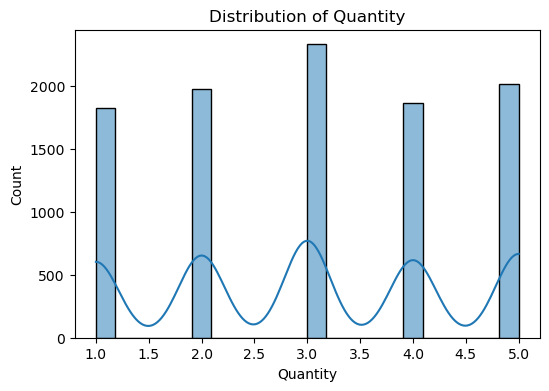

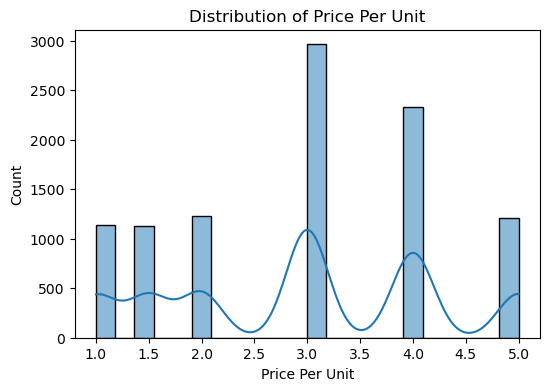

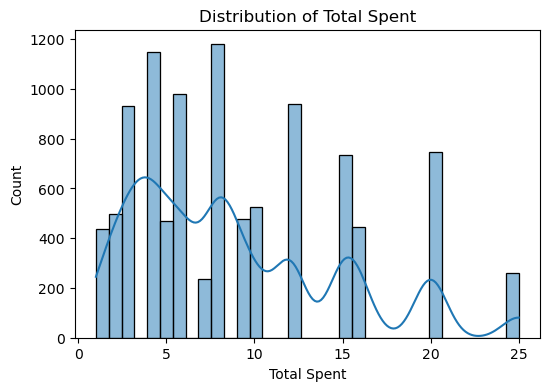

In [67]:
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Histogram of Total Spent
Most customers spend a moderate amount per transaction. A few transactions have much higher spending, creating a right-skewed distribution.

# Histogram of Quantity
Most customers purchase a small number of items. Larger purchases occur less frequently.

# Histogram Price Per Unit
Most products are sold within a common price range, while very high-priced items are less common.


# Bar Chart

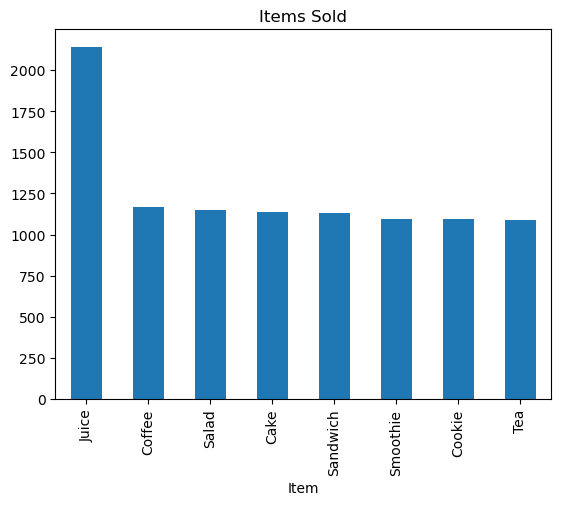

In [68]:
df['Item'].value_counts().plot(kind='bar')
plt.title('Items Sold')
plt.show()

# Bar Chart of Item

This bar chart shows the number of sales for each item. Taller bars represent items that were sold more frequently. It helps identify the most popular and least popular products in the cafe.

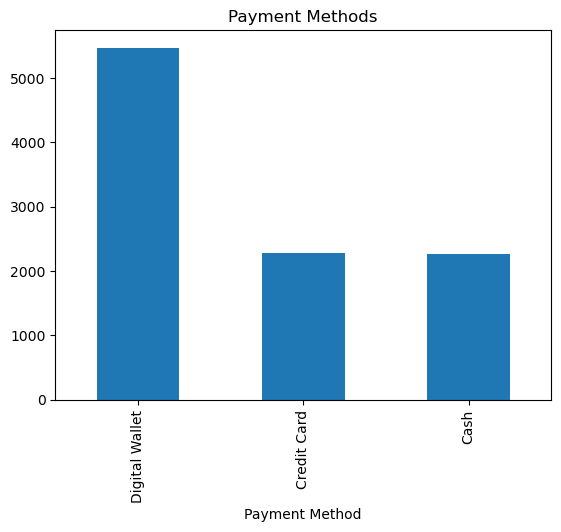

In [69]:
df['Payment Method'].value_counts().plot(kind='bar')
plt.title('Payment Methods')
plt.show()

# Bar Chart of Payment Method
This chart displays the frequency of different payment methods used by customers. It helps determine which payment method is preferred the most. Businesses can use this information to improve payment services.

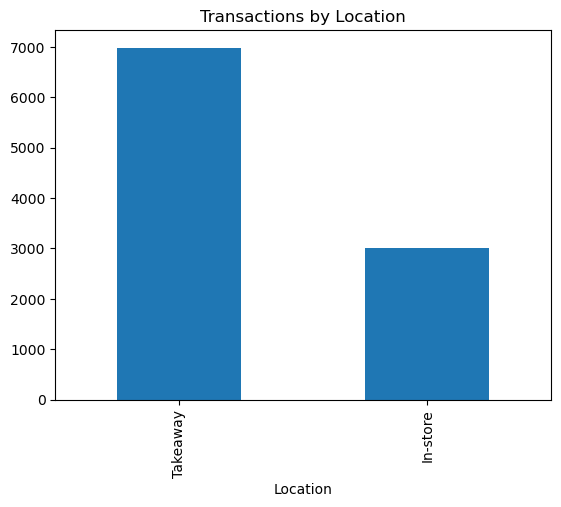

In [70]:
df['Location'].value_counts().plot(kind='bar')
plt.title('Transactions by Location')
plt.show()

# Bar Chart of Location
This bar chart shows the number of transactions recorded at each location. Locations with taller bars have more customer activity. It helps identify the busiest café locations.

# Box Plot

<Axes: ylabel='Total Spent'>

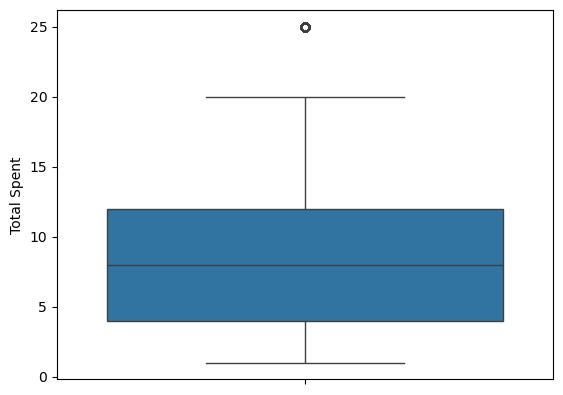

In [71]:
sns.boxplot(y=df['Total Spent'])

# Box Plot of Total Spent
The box plot shows the spread of customer spending and identifies several high-spending outliers.

<Axes: ylabel='Price Per Unit'>

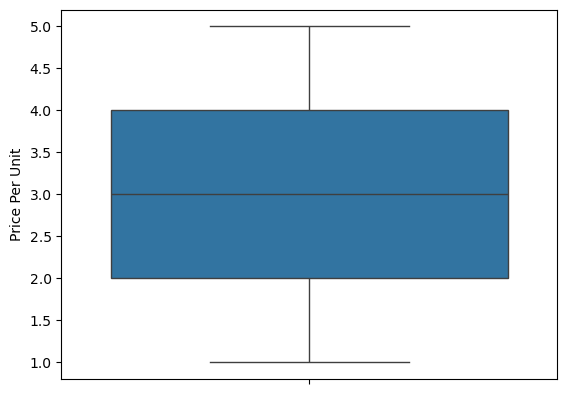

In [72]:
sns.boxplot(y=df['Price Per Unit'])

# Box Plot: Price Per Unit

Product prices are generally concentrated within a limited range, with some extreme values appearing as outliers.

<Axes: ylabel='Quantity'>

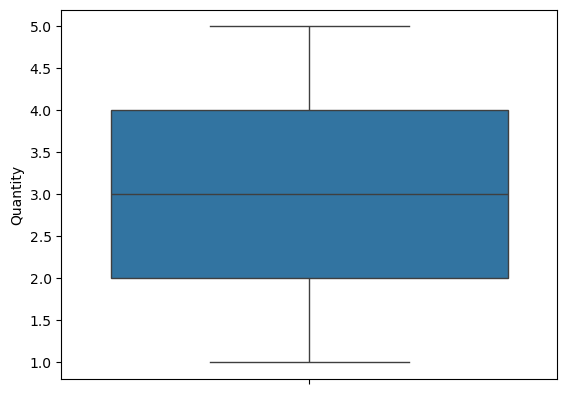

In [73]:
sns.boxplot(y=df['Quantity'])

# Box Plot: Quantity

Most purchases involve a small quantity of items, although a few transactions contain unusually large quantities.

# Scatter Plot

<Axes: xlabel='Quantity', ylabel='Total Spent'>

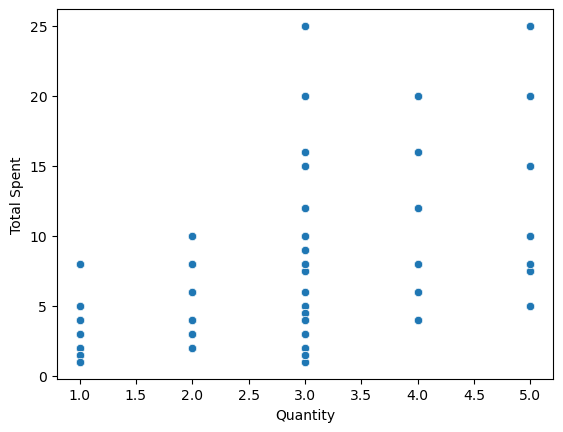

In [74]:
sns.scatterplot(
    x='Quantity',
    y='Total Spent',
    data=df
)

# Scatter Plot: Quantity vs Total Spent

There is a positive relationship between quantity purchased and total spending. Customers who buy more items generally spend more money.

<Axes: xlabel='Price Per Unit', ylabel='Total Spent'>

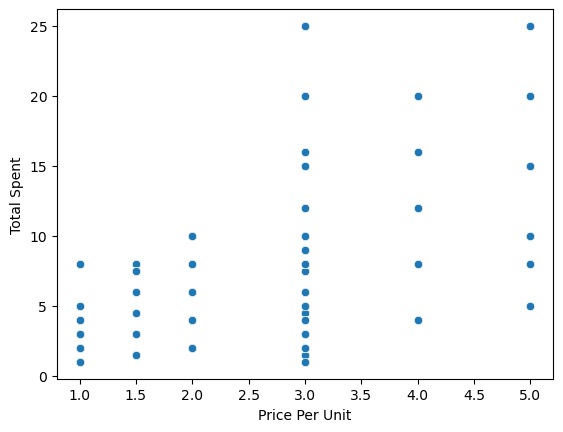

In [75]:
sns.scatterplot(
    x='Price Per Unit',
    y='Total Spent',
    data=df
)

# Scatter Plot: Price Per Unit vs Total Spent

Higher-priced items tend to contribute to larger transaction amounts, although the relationship is not perfectly linear.

#  Correlation Heatmap

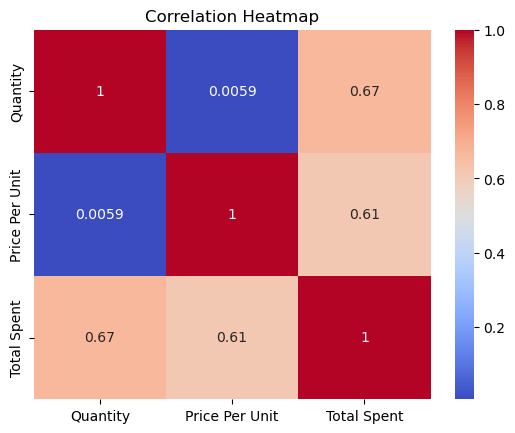

In [92]:
numeric_df = df[['Quantity',
                 'Price Per Unit',
                 'Total Spent']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# Correlation Heatmap

Quantity and Total Spent show a strong positive correlation. Price Per Unit also has a positive relationship with Total Spent.

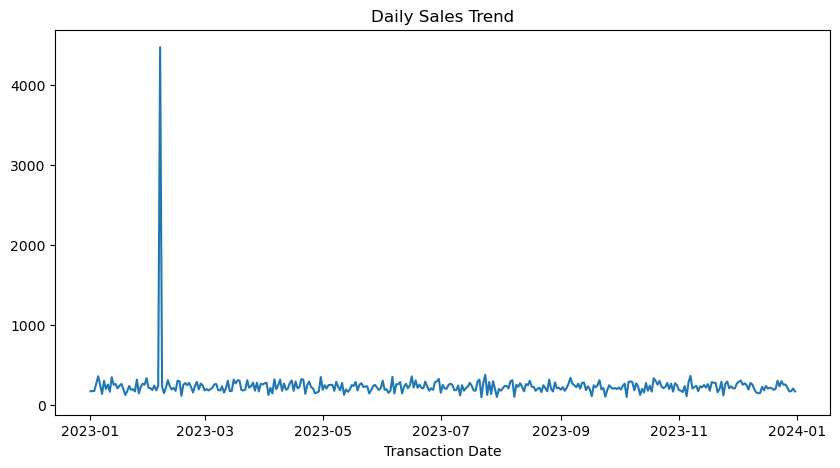

In [77]:
daily_sales = df.groupby(
    df['Transaction Date'].dt.date
)['Total Spent'].sum()

daily_sales.plot(figsize=(10,5))
plt.title('Daily Sales Trend')
plt.show()

# Daily Sales Trend

Sales fluctuate over time, indicating variation in customer purchasing behavior across different days.

#  Descriptive Statistics

In [78]:
df[['Quantity','Price Per Unit','Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,10000.000000,10000.00000,10000.00000
mean,3.027100,2.95265,8.87795
std,1.384614,1.24396,5.86059
min,1.000000,1.00000,1.00000
25%,2.000000,2.00000,4.00000
50%,3.000000,3.00000,8.00000
75%,4.000000,4.00000,12.00000
max,5.000000,5.00000,25.00000


# Minimum and Maximum 

These values show the smallest and largest observations in the dataset.

In [82]:
df[['Quantity','Price Per Unit','Total Spent']].mode()

,Quantity,Price Per Unit,Total Spent
0,3.0,3.0,8.0


#
For Quantity, the mode indicates the quantity most commonly purchased by customers.

# Variance 

In [83]:
df[['Quantity','Price Per Unit','Total Spent']].var()

Quantity           1.917157
Price Per Unit     1.547438
Total Spent       34.346513
dtype: float64

# 
Variance indicates the degree of spread in the data. Larger values imply greater variability.

# IQR

In [84]:
Q1 = df[['Quantity','Price Per Unit','Total Spent']].quantile(0.25)
Q3 = df[['Quantity','Price Per Unit','Total Spent']].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

Quantity          2.0
Price Per Unit    2.0
Total Spent       8.0
dtype: float64


# 
Quartiles divide the data into four equal parts. The IQR measures the spread of the middle 50% of observations and helps identify outliers.

# Median

In [86]:
df[['Quantity','Price Per Unit','Total Spent']].median()

Quantity          3.0
Price Per Unit    3.0
Total Spent       8.0
dtype: float64

#
The median represents the middle value and is less affected by extreme values than the mean.

# Mean

In [87]:
df[['Quantity','Price Per Unit','Total Spent']].mean()

Quantity          3.02710
Price Per Unit    2.95265
Total Spent       8.87795
dtype: float64

 #
The mean represents the average value of the dataset and provides a measure of central tendency.

# Standard Deviation

In [90]:
std_dev = df[['Quantity','Price Per Unit','Total Spent']].std()

print(std_dev)

Quantity          1.384614
Price Per Unit    1.243960
Total Spent       5.860590
dtype: float64


# 
Standard deviation measures how much the values vary from the average.

# Hypothesis Formulation and Statistical Testing

# Research Question
Does purchasing a larger quantity lead to higher customer spending?

# Null Hypothesis (H₀)

#
There is no significant relationship between Quantity and Total Spent.

# Alternative Hypothesis (H₁)

#
There is a significant positive relationship between Quantity and Total Spent.

# Correlation Test

#
from scipy.stats import pearsonr

It evaluates how strongly two continuous variables are connected via a linear relationship



In [88]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df['Quantity'],
    df['Total Spent']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6688206080029753
P-value: 0.0


# Interpretation
correlation Coefficient (r = 0.6688)
The correlation value is positive.
It is close to 0.7, indicating a moderately strong positive relationship between Quantity and Total Spent.
As customers purchase more items, their total spending generally increases.

# P-value (0.0)
The p-value is less than 0.05.
Therefore, the result is statistically significant.

# Conclusion
Since  p-value < 0.05  so that Reject the Null Hypothesis (H₀). and Accept the Alternative Hypothesis (H₁): which mean There is a statistically significant positive relationship between Quantity and Total Spent. 